# Python Audio Synthesis Masterclass

Welcome to your interactive synthesizer! This notebook walks you through 17 core concepts of audio synthesis using raw math and Python.

**Instructions:** Run the cells sequentially. Make sure your speakers/headphones are at a moderate volume!

## 0. Setup: The Engine Room
First, we import our libraries and define two helper functions:
1. `play_sound()`: Normalizes the audio to prevent distortion and plays it.
2. `plot_waves()`: Draws the waveforms so we can visualize our math.

In [103]:
import numpy as np
import sounddevice as sd
import matplotlib.pyplot as plt
import scipy.signal as signal

sample_rate = 44100
duration = 3.0 # default duration of 1 second
t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)

def play_sound(audio_array):
    '''Normalizes audio to safe levels (-1.0 to 1.0) and plays it.'''
    # max_amp = np.max(np.abs(audio_array))
    # if max_amp > 0:
    #     audio_array = audio_array / max_amp
    # Reduce volume to 50% for safety
    # audio_array = audio_array # * 0.5 
    sd.play(audio_array, sample_rate)
    sd.wait()

def plot_waves(waves, titles, x_lim=(0, 0.02)):
    '''Helper to plot one or multiple waves stacked.'''
    num_plots = len(waves)
    fig, axes = plt.subplots(num_plots, 1, figsize=(10, 2.5 * num_plots))
    if num_plots == 1: axes = [axes]
    
    for ax, wave, title in zip(axes, waves, titles):
        ax.plot(t, wave, color='teal')
        ax.set_title(title)
        ax.set_xlim(x_lim)
        ax.grid(True)
    plt.tight_layout()
    plt.show()

---
## PART 1: The Basics
### 1 & 2. Sound Wave Generation & Audio Playback
Sound is just changing air pressure over time. In a computer, we represent this as an array of numbers. A Sine Wave is the purest sound, containing only one fundamental frequency.

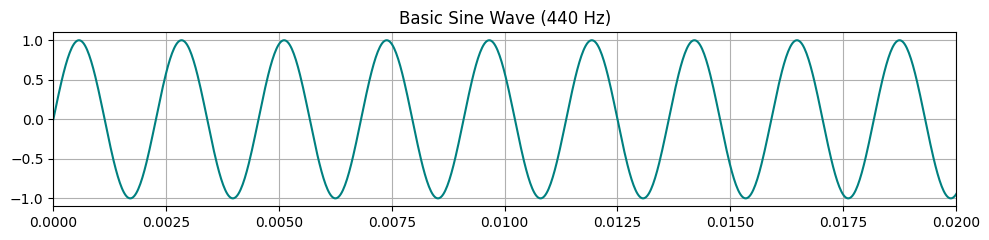

In [16]:
# Generate a 440 Hz Sine Wave (Musical note A4)
freq = 440.0
sine_wave = np.sin(2 * np.pi * freq * t)

plot_waves([sine_wave], ['Basic Sine Wave (440 Hz)'])
play_sound(sine_wave)

### 3. Change of Pitch and Amplitude
- **Pitch** is controlled by the Frequency multiplier (higher number = faster vibration = higher pitch).
- **Amplitude** (Volume) is controlled by multiplying the entire wave by a fraction.

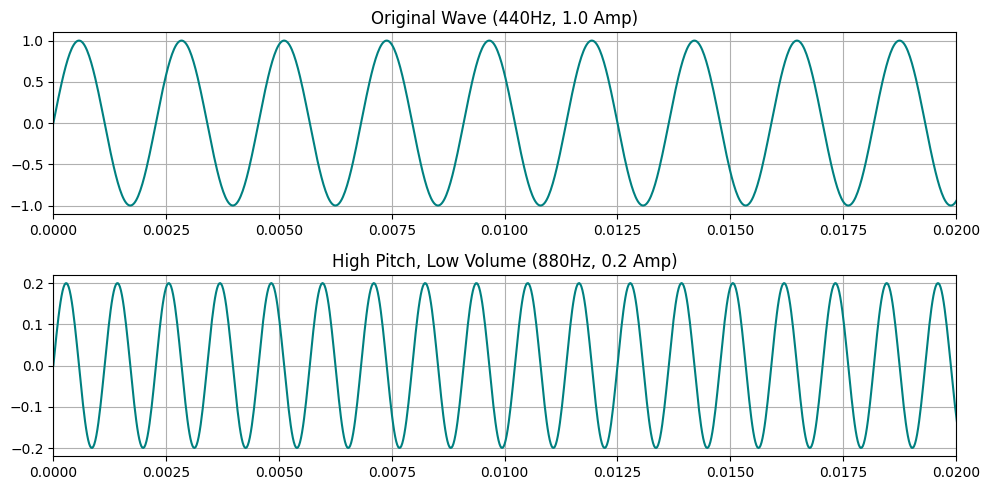

In [20]:
pitch_high = 880.0  # An octave higher
amplitude_low = 0.2 # 20% volume

high_quiet_wave = amplitude_low * np.sin(2 * np.pi * pitch_high * t)

plot_waves([sine_wave, high_quiet_wave], ['Original Wave (440Hz, 1.0 Amp)', 'High Pitch, Low Volume (880Hz, 0.2 Amp)'])
play_sound(high_quiet_wave)

---
## PART 2: Combining Waves
### 4. Intervals (Musical Math)
When you play two notes together, they sound pleasing if their frequencies form simple mathematical ratios. A 'Perfect Fifth' is a ratio of 1.5 (3:2).

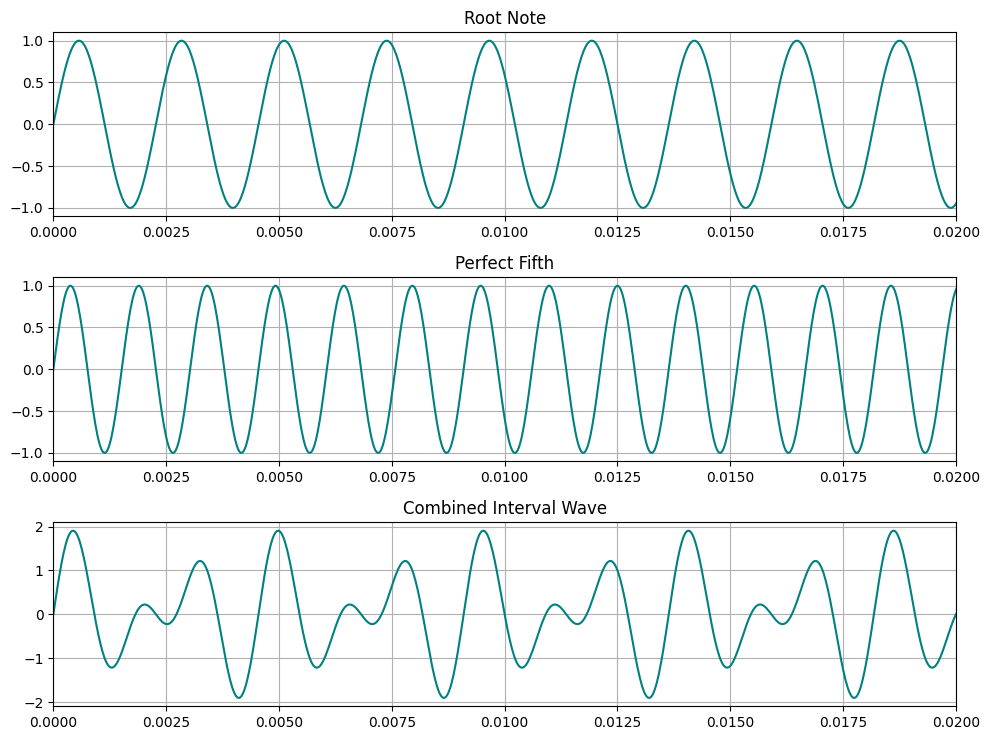

In [25]:
root_wave = np.sin(2 * np.pi * 440 * t)
fifth_wave = np.sin(2 * np.pi * (440 * 1.5) * t) # 660 Hz

# Adding them together creates a chord!
interval_wave = root_wave + fifth_wave

plot_waves([root_wave, fifth_wave, interval_wave], 
           ['Root Note', 'Perfect Fifth', 'Combined Interval Wave'])
play_sound(interval_wave)

### 5. Stacking Oscillations (Beating / Chorus Effect)
What happens if we add two waves that are almost identical, but off by just 2 Hz? They move in and out of phase, creating a 'wobbly' beating effect.

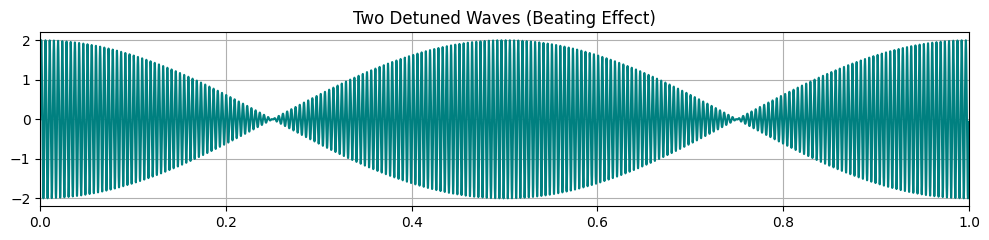

In [48]:
wave_a = np.sin(2 * np.pi * 220 * t)
wave_b = np.sin(2 * np.pi * 222 * t) # Detuned by 2 Hz

beating_wave = wave_a + wave_b

# We visualize a full second here to see the slow volume wobble
plot_waves([beating_wave], ['Two Detuned Waves (Beating Effect)'], x_lim=(0, 1.0))
play_sound(beating_wave)

### 6. Harmonic Addition & Additive Synthesis
Additive synthesis builds complex sounds by adding simple sine waves together. According to Fourier, *any* sound can be built this way! Here, we build a Square wave by adding odd harmonics.

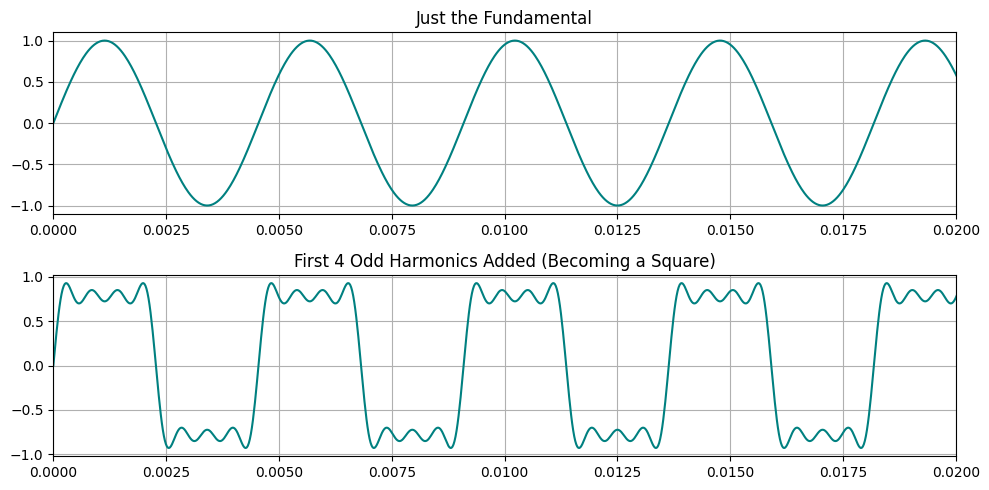

In [55]:
f = 220.0
harmonic_1 = np.sin(2 * np.pi * f * t)
harmonic_3 = (1/3) * np.sin(2 * np.pi * (f * 3) * t)
harmonic_5 = (1/5) * np.sin(2 * np.pi * (f * 5) * t)
harmonic_7 = (1/7) * np.sin(2 * np.pi * (f * 7) * t)

additive_square = harmonic_1 + harmonic_3 + harmonic_5 + harmonic_7

plot_waves([harmonic_1, additive_square], 
           ['Just the Fundamental', 'First 4 Odd Harmonics Added (Becoming a Square)'])
play_sound(additive_square)

### 7. Fine Tune and Supersaw
The 'Supersaw' is an iconic electronic music sound (Trance/EDM) made by stacking many Sawtooth waves and detuning them all slightly from the center pitch.

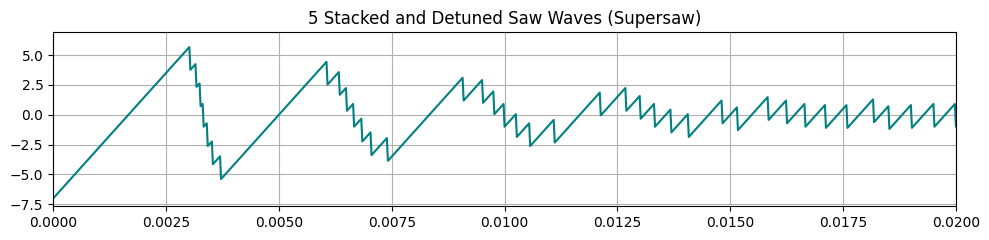

In [101]:
base_f = 300.0 # Deep bass note
detune_amounts = [-30.0, -15.5, -7.6, 0.0, 7.6, 15.5, 30.0] # Detune in Hz

supersaw = np.zeros_like(t)
for d in detune_amounts:
    # signal.sawtooth creates a harsh, buzzy wave
    supersaw += signal.sawtooth(2 * np.pi * (base_f + d) * t)

plot_waves([supersaw], ['5 Stacked and Detuned Saw Waves (Supersaw)'])
play_sound(supersaw)

---
## PART 3: Sculpting Sound
### 8. Usage of Noises
White noise contains every frequency at once, randomized. We use NumPy's random generator to create it. It sounds like a TV static.

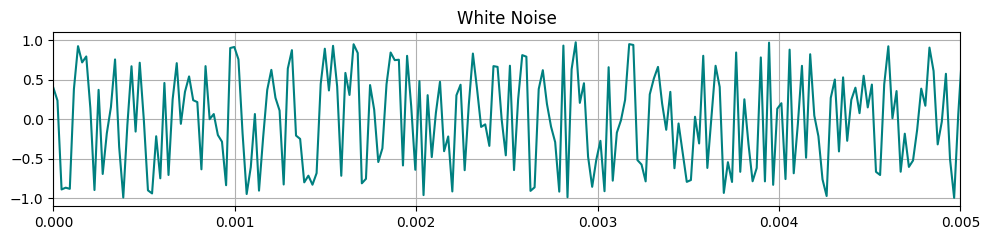

In [105]:
# Generate random numbers between -1.0 and 1.0
white_noise = np.random.uniform(-1.0, 1.0, len(t))

plot_waves([white_noise], ['White Noise'], x_lim=(0, 0.005)) # Zoomed in tight
play_sound(white_noise)

### 9 & 10. Modification & Subtractive Synthesis
Subtractive synthesis is the opposite of Additive. You start with a very rich sound (like Noise or a Sawtooth) and use **Filters** to carve away frequencies you don't want. Here we apply a Lowpass Filter.

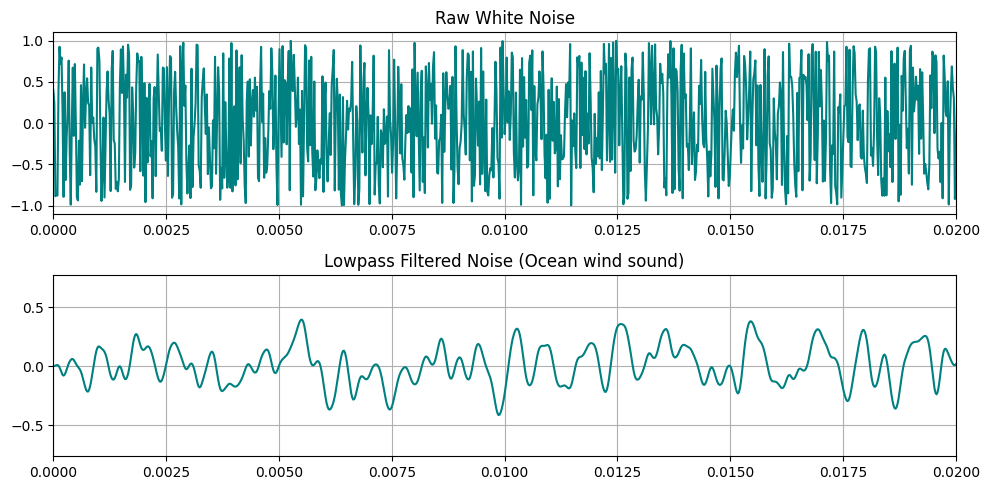

In [111]:
# Create a Butterworth Lowpass Filter
cutoff_hz = 2000.0  # Frequencies above this will be muted
nyquist = sample_rate / 2.0
b, a = signal.butter(4, cutoff_hz / nyquist, btype='low')

# Apply filter to the white noise from the previous cell
filtered_noise = signal.lfilter(b, a, white_noise)

plot_waves([white_noise, filtered_noise], 
           ['Raw White Noise', 'Lowpass Filtered Noise (Ocean wind sound)'], 
           x_lim=(0, 0.02))
play_sound(filtered_noise)

---
## PART 4: Advanced Synthesis Techniques
### 11. Wavetable Synthesis
Instead of computing `np.sin()` for every single sample, Wavetable synthesis pre-computes one single cycle of a wave into a 'table' (array), and plays back the sound by scanning through that array at different speeds.

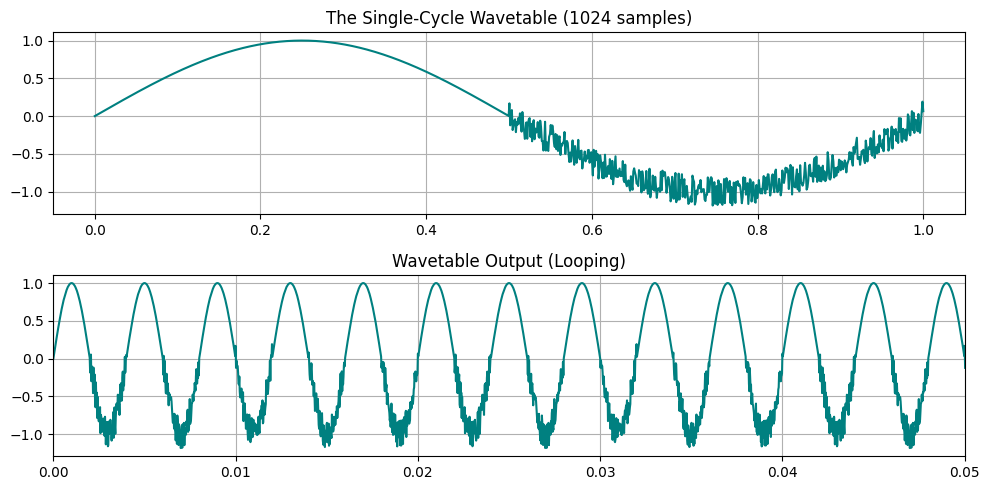

In [118]:
# 1. Create the 'Table' (1024 points of a custom wave shape)
table_length = 1024
table_x = np.linspace(0, 1, table_length)
# Let's make a weird custom wave: Half sine, half noise
wavetable = np.sin(2 * np.pi * table_x)
wavetable[512:] += np.random.uniform(-0.2, 0.2, 512)

# 2. Scan through the table to generate sound
play_freq = 250.0
phase = 0.0
wavetable_output = np.zeros_like(t)

for i in range(len(t)):
    # Find where we are in the table
    index = int((phase % 1.0) * table_length)
    wavetable_output[i] = wavetable[index]
    # Move the phase forward based on desired pitch
    phase += play_freq / sample_rate

# 3. Visualize (Custom plot to handle the different array sizes)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5))

# Plot the 1024-sample table against its phase (0 to 1)
ax1.plot(table_x, wavetable, color='teal')
ax1.set_title('The Single-Cycle Wavetable (1024 samples)')
ax1.grid(True)

# Plot the actual generated audio against time (t)
ax2.plot(t, wavetable_output, color='teal')
ax2.set_title('Wavetable Output (Looping)')
ax2.set_xlim(0, 0.05) # Zoom in to see the looping shape
ax2.grid(True)

plt.tight_layout()
plt.show()

# 4. Play the sound
play_sound(wavetable_output)

### 12. FM Synthesis (Frequency Modulation)
Made famous by 80s synths like the Yamaha DX7. You use one wave (Modulator) to rapidly wiggle the pitch of another wave (Carrier). This creates complex, metallic, bell-like harmonics.

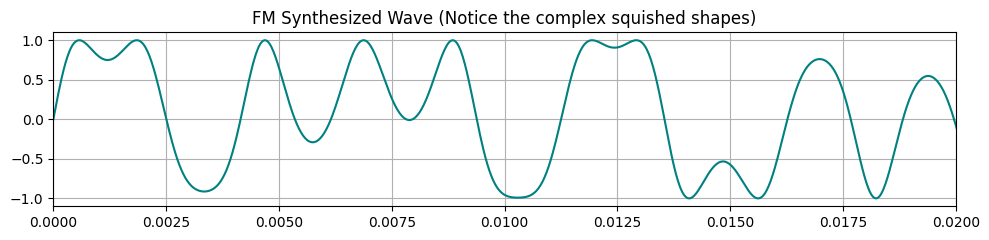

In [128]:
carrier_freq = 40.0
modulator_freq = 220.0 # Ratio of 2:1
modulation_index = 2.0 # How intensely the pitch is wiggled

modulator_wave = modulation_index * np.sin(2 * np.pi * modulator_freq * t)
# The modulator is added directly into the phase/frequency math of the carrier
fm_wave = np.sin(2 * np.pi * carrier_freq * t + modulator_wave)

plot_waves([fm_wave], ['FM Synthesized Wave (Notice the complex squished shapes)'])
play_sound(fm_wave)

### 13. Waveshaping (Distortion)
Waveshaping applies a mathematical function to deform a wave. The most common is overdrive/saturation, which squashes the tops off of round waves, adding harsh harmonics.

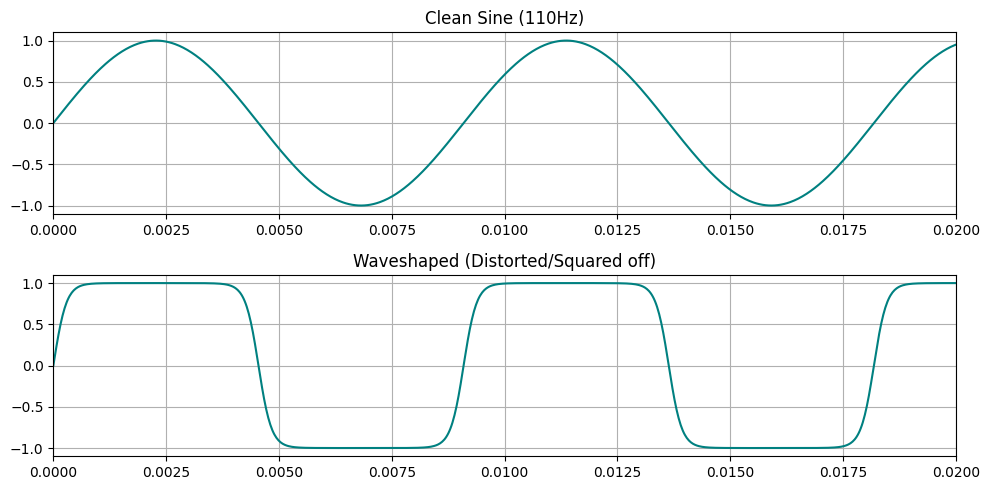

In [132]:
clean_sine = np.sin(2 * np.pi * 110 * t)
drive_amount = 5.0

# Hyperbolic Tangent (tanh) is a classic soft-clipping distortion algorithm
distorted_wave = np.tanh(clean_sine * drive_amount)

plot_waves([clean_sine, distorted_wave], 
           ['Clean Sine (110Hz)', 'Waveshaped (Distorted/Squared off)'])
play_sound(distorted_wave)

### 14. Hardsync
Two oscillators. The 'Master' dictates the pitch. Every time the Master finishes a cycle, it forces the 'Slave' oscillator to instantly reset to zero, creating a sharp, tearing waveform.

/tmp/ipykernel_42101/154585184.py:31: UserWarning: Glyph 2349 (\N{DEVANAGARI LETTER BHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_42101/154585184.py:31: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_42101/154585184.py:31: UserWarning: Glyph 2368 (\N{DEVANAGARI VOWEL SIGN II}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/mnt/D/projects/Bobot_3/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2349 (\N{DEVANAGARI LETTER BHA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/mnt/D/projects/Bobot_3/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)
/mnt/D/projects/Bobot_3/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2368 (\N{DEVANAGARI VOWEL SIGN II}) missin

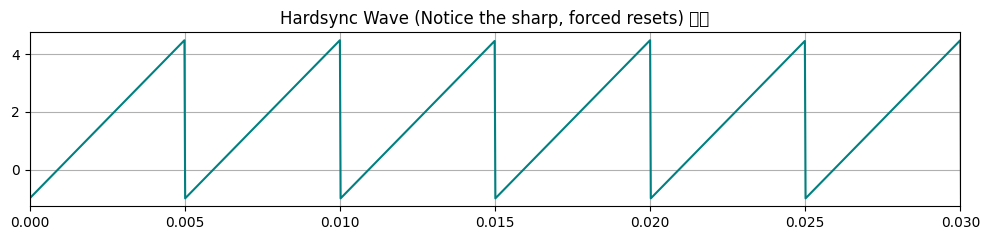

In [133]:
freq_master = 200.0
freq_slave = 550.0

sync_wave = np.zeros_like(t)
phase_master = 0.0
phase_slave = 0.0

for i in range(len(t)):
    # Generate sawtooth value for slave
    sync_wave[i] = 2.0 * phase_slave - 1.0 
    
    phase_slave += freq_slave / sample_rate
    phase_master += freq_master / sample_rate
    
    # HARDSYNC: If master crosses 1.0 (finishes a cycle), reset slave instantly
    if phase_master >= 1.0:
        phase_master -= 1.0
        phase_slave = 0.0 

plot_waves([sync_wave], ['Hardsync Wave (Notice the sharp, forced resets) भी'], x_lim=(0, 0.03))
play_sound(sync_wave)

### 15. Granular Synthesis
Granular synthesis takes an existing sound, cuts it into tiny micro-snippets called 'grains' (e.g., 50 milliseconds), and scatters them, overlaps them, or changes their pitch to create a textured, ambient sound cloud.

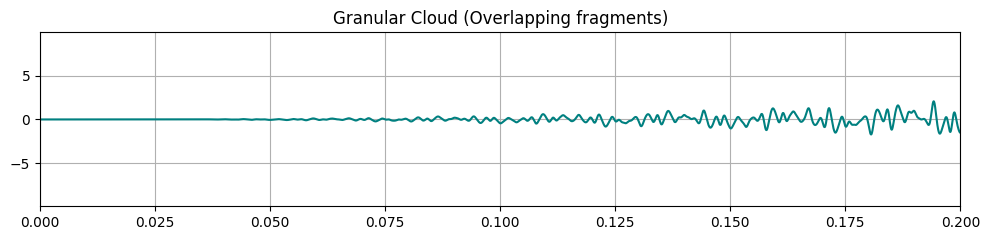

In [142]:
# Our 'source' audio will be the FM wave we made earlier
source_audio = fm_wave 
grain_length = int(0.5 * sample_rate) # 50 millisecond grains
num_grains = 200

granular_cloud = np.zeros_like(t)

# Apply a window (envelope) so grains don't click when cut
window = np.hanning(grain_length)

for _ in range(num_grains):
    # 1. Pick a random starting point in the source audio
    src_start = np.random.randint(0, len(source_audio) - grain_length)
    grain = source_audio[src_start : src_start + grain_length] * window
    
    # 2. Place it at a random time in our new output wave
    out_start = np.random.randint(0, len(granular_cloud) - grain_length)
    granular_cloud[out_start : out_start + grain_length] += grain

plot_waves([granular_cloud], ['Granular Cloud (Overlapping fragments)'], x_lim=(0, 0.2))
play_sound(granular_cloud)

---
### Conclusion
You have successfully programmed everything from a basic sine wave to advanced Granular and FM synthesis using nothing but raw mathematics in Python!

**Where to go next:** Try changing the parameters (like `cutoff_hz` in the filter, or the `modulation_index` in FM) and run the cells again to hear how the math changes the music.